In [22]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack


In [1]:
pip install streamlit-audiorecorder


Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("ASAP2_train_sourcetexts.csv")
df


,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24723,AAAOPP13416000001321_cleaned,2,"Hello, my name is STUDENT_NAME. I think driver...","In the article “Driverless Cars are Coming,” t...",Driverless cars,Not economically disadvantaged,Not identified as having disability,Yes,White,M,Driverless Cars Are Coming \nCan you imagine a...,NaN,NaN,NaN
24724,5164392_cleaned,3,What you are about to read is going to give yo...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...
24725,5057454_cleaned,1,umm yeah just dont drive as much you can save ...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...
24726,5179241,2,if we look back at time in the united states y...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...


In [4]:
df = df[['full_text', 'score']].dropna()
df = df.sample(5000, random_state=42).reset_index(drop=True)

In [5]:
df.head()

,full_text,score
0,Driverless cars are a good inovention for the ...,3
1,I think what they are trying to say is that be...,2
2,Have you ever wanted to go around the world he...,2
3,The advantages of limitng car use can be a ben...,3
4,"In 1976 , NASA took a picture of the Cydonia a...",2


In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)
    return text.strip()

df['cleaned'] = df['full_text'].apply(clean_text)

In [7]:
def filler_ratio(text):
    fillers = ['um', 'uh', 'er', 'like', 'you know']
    words = text.split()
    if len(words) == 0:
        return 0
    return sum(words.count(f) for f in fillers) / len(words)

df['filler_ratio'] = df['cleaned'].apply(filler_ratio)

In [8]:
def sentence_count(text):
    return len(sent_tokenize(text))

df['sent_count'] = df['cleaned'].apply(sentence_count)

In [9]:
def sentence_length_variance(text):
    sentences = sent_tokenize(text)
    lengths = [len(s.split()) for s in sentences]
    return np.var(lengths) if len(lengths) > 1 else 0

df['length_var'] = df['cleaned'].apply(sentence_length_variance)

In [10]:
def short_sentence_ratio(text):
    sentences = sent_tokenize(text)
    if not sentences:
        return 0
    short = [s for s in sentences if len(s.split()) <= 3]
    return len(short) / len(sentences)

df['short_ratio'] = df['cleaned'].apply(short_sentence_ratio)

In [11]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def sentence_coherence(text):
    sentences = sent_tokenize(text)
    if len(sentences) < 2:
        return 0.0
    embeddings = embedder.encode(sentences, show_progress_bar=False)
    sims = cosine_similarity(embeddings[:-1], embeddings[1:])
    return np.mean(sims)

df['sent_coherence'] = df['cleaned'].apply(sentence_coherence)

In [12]:
tfidf = TfidfVectorizer(
    max_features=800,   # reduced on purpose
    min_df=10,
    ngram_range=(1, 1)
)

X_tfidf = tfidf.fit_transform(df['cleaned'])

In [13]:
speech_features = np.column_stack([
    df['sent_coherence'] * 3.0,
    df['length_var'] * 2.0,
    df['filler_ratio'] * -5.0,
    df['sent_count'] * 1.0,
    df['short_ratio'] * -4.0
])

X = hstack([X_tfidf, speech_features])
y = df['score']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

RMSE: 0.703
MAE: 0.548


In [17]:
bad = "um uh um uh like like um"
good = """
Today I will explain artificial intelligence.
First, I will define the concept.
Then, I will discuss real-world applications.
Finally, I will summarize the key points.
"""

def score_transcript(text):
    cleaned = clean_text(text)
    
    features = np.array([[
        sentence_coherence(cleaned) * 3.0,
        sentence_length_variance(cleaned) * 2.0,
        filler_ratio(cleaned) * -5.0,
        sentence_count(cleaned) * 1.0,
        short_sentence_ratio(cleaned) * -4.0
    ]])
    
    X_tfidf_new = tfidf.transform([cleaned])
    X_new = hstack([X_tfidf_new, features])
    
    raw_score = rf.predict(X_new)[0]

    normalized = 100 * (raw_score - y.min()) / (y.max() - y.min())
    return raw_score, normalized

print("BAD:", score_transcript(bad))
print("GOOD:", score_transcript(good))

BAD: (1.7533333333333334, 15.066666666666668)
GOOD: (1.99, 19.8)


In [18]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

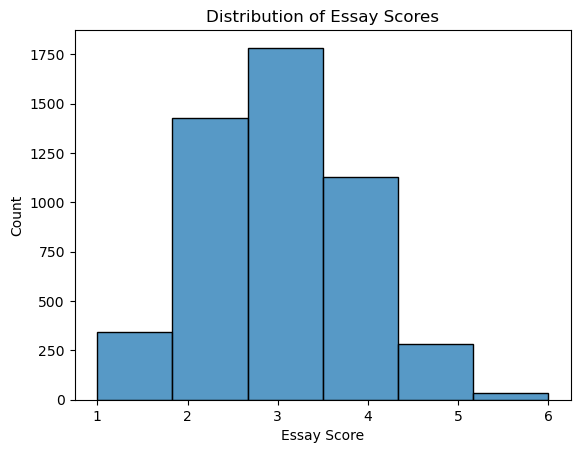

In [24]:
plt.figure()
sns.histplot(df['score'], bins=6)
plt.xlabel("Essay Score")
plt.ylabel("Count")
plt.title("Distribution of Essay Scores")
plt.show()

In [26]:
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))


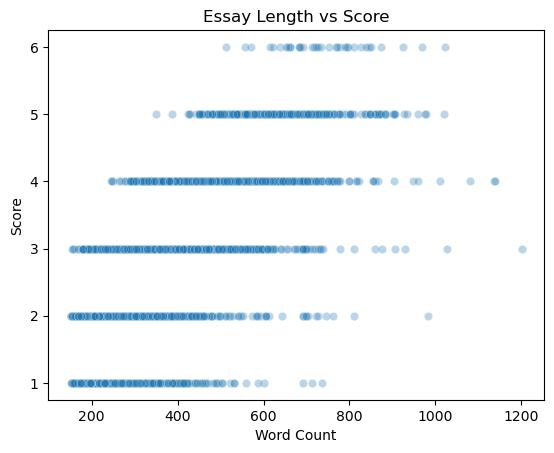

In [27]:
plt.figure()
sns.scatterplot(x=df['word_count'], y=df['score'], alpha=0.3)
plt.xlabel("Word Count")
plt.ylabel("Score")
plt.title("Essay Length vs Score")
plt.show()

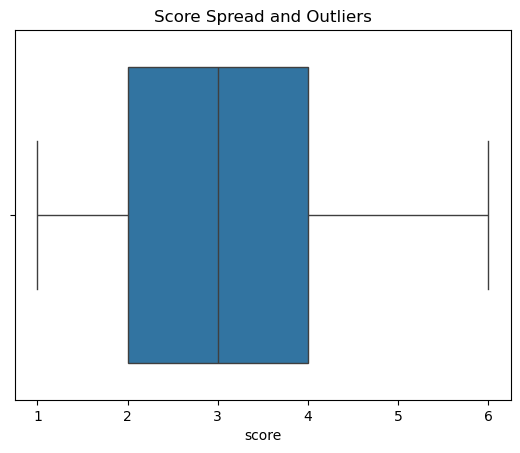

In [28]:
plt.figure()
sns.boxplot(x=df['score'])
plt.title("Score Spread and Outliers")
plt.show()

In [29]:
importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()


IndexError: index 801 is out of bounds for axis 0 with size 800

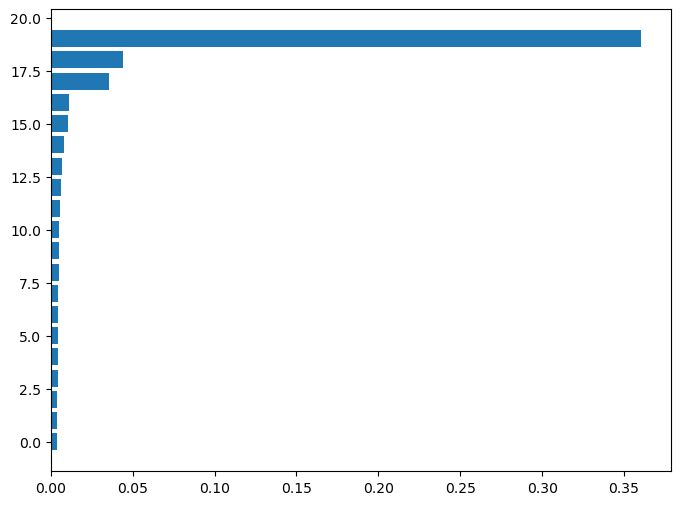

In [30]:
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel("Importance")
plt.title("Top 20 Most Important TF-IDF Features")
plt.show()
